## Setup for EDA and time series 

In [3]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name

from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| dtype: objectres_df.columns |

#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [ ]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [ ]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

In [ ]:
#res_df.dtypes

In [ ]:
res_df.info()

In [ ]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

#### Here we add new columns to data frame 

In [ ]:

# Here we add new columns to data frame 
data_df_mwh['solar_by_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['total_energy_minus_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']
data_df_mwh.head()


#### We capitalize the columns names

In [ ]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [ ]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [ ]:
data_df_gwh = data_df_mwh.copy()

In [ ]:
#data_df_mwh['Marine_mwh']

In [ ]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Total_energy_minus_solar_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [ ]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [ ]:
data_df_gwh.head()    

#### 'data_df' set the unit of final processing data

In [ ]:

data_df= data_df_gwh.copy()

In [ ]:
data_df.head()

In [ ]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [ ]:
##data_df.columns

In [ ]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [ ]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
#main_0  = 'Total_energy_generation_mwh' # This is only for energy
main_0  = 'Solar_gwh'
title_main = main_0.replace('_', ' ').replace('gwh', 'energy generation')
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', ' energy generation (GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


### Here we set the function for line plot  

In [ ]:
def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'energy in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'energy in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()


def average_lineplot_subgroup(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    #fig, ax = plt.subplots()
    #fig,ax = plt.subplots(13,2 ,figsize=(16,4))
    count = 0
    plt.subplots(nrows=13, ncols=1, figsize=(20, 12)) 
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax[count])
    count = +1
    #ylable_00  = y.replace('_gwh', '(gwh)')
    #ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
#fig,ax = plt.subplots(1, 3,figsize=(16,4))
#count = 0
#for col in plot_col:
#    sns.histplot(df_train[col], kde=True, ax=ax[count], color='#33658A').set(title=col, xlabel='')
#    #plt.axvlines(X_train[col].mean(), 0, X_train[col].max(), color="red")
#    count += 1
#fig.tight_layout(pad=3)

In [ ]:
# Energy_mwh or Solar_mwh  development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [ ]:
data_df.columns

In [ ]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar_by_energy', 'Total_energy_minus_solar_gwh',
#             'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Waste_gwh', 'Solar_gwh', 'Other_renewable_gwh',  
#             'Marine_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',  'Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

In [ ]:
# Plot distribution of numerical features with missing values 
#fig,ax = plt.subplots(13, 3,figsize=(16,4))
#count = 0
#for col in ycol_aggr:
#    daily_data_df_c = data_df \
#        .groupby(['Date', 'Year'], as_index=False)\
#            .agg({col: np.sum}) \
#                .set_index('Date')

#count = 0
#plt.subplots(nrows=13, ncols=1, figsize=(20, 12)) 
#sns.lineplot(x="Date", y=col, data=daily_data_df_c, ax=ax[count])
#count = +1


    
   # average_lineplot_subgroup(df=data_df, y=col, x="Date", time='Year')
    #average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year', kde=True, ax=ax[count], color='#33658A')
    #sns.histplot(df_train[col], kde=True, ax=ax[count], color='#33658A').set(title=col, xlabel='')
   # count += 1
#fig.tight_layout(pad=3)

In [ ]:
#average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [ ]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [ ]:
daily_data_df

In [ ]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Day', target]], index='Day', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Daily)', ylabel=ylable_target);

#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [ ]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Month', target]], index='Month', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title=  title_main +' '+'-'+' ' + ' ' +'Yearly(Monthly)', ylabel=ylable_target);

#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [ ]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Hour', target]], index='Hour', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title=title_main +' '+'-'+' ' + ' ' +'Yearly(Hourly)', ylabel=ylable_target);

#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [ ]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

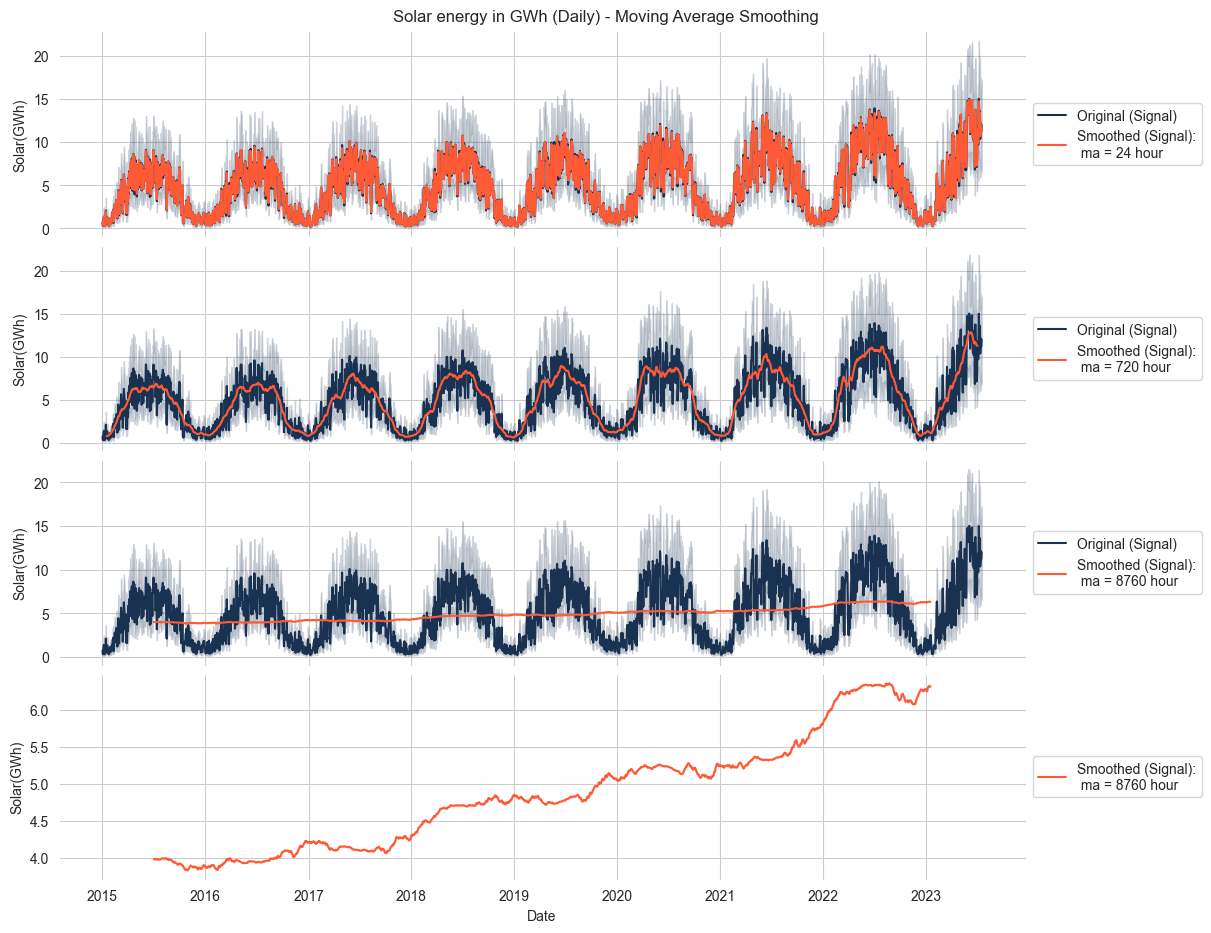

In [82]:
# Plot moving average of different length (week, month, year)
#ma = [7, 30, 365]
ma = [24, 30*24, 365*24]

smooth_daily_data_df = daily_data_df \
    .reset_index() \
    .assign(date = lambda x: x['Date'].transform(pd.to_datetime))

# Smooth and plot
fig, ax = plt.subplots(len(ma)+1, 1, figsize=(12, 9), constrained_layout=True, sharex=True)
plt.suptitle(title_main + ' ' + '(Daily) - Moving Average Smoothing', y=1.02);

for i, m in enumerate(ma):
    smooth_daily_data_df[f'target_SE_smooth_ma_{m}'] = smooth_daily_data_df[target].rolling(window=m,center=True).mean() #compute the rolling mean

    sns.lineplot(x='Date', y=target, label='Original (Signal)', data=smooth_daily_data_df,  ax=ax[i])
    sns.lineplot(x='Date', y=f'target_SE_smooth_ma_{m}', label=f'Smoothed (Signal):\n ma = {m} hour', data=smooth_daily_data_df, color=NF_ORANGE, ax=ax[i])

    ax[i].legend(title='', loc='center left', bbox_to_anchor=(1, 0.5))
    ax[i].set(title='', ylabel=ylable_target);
        
sns.lineplot(x='Date', y=f'target_SE_smooth_ma_{m}', label=f'Smoothed (Signal):\n ma = {m} hour', data=smooth_daily_data_df, color=sns_c[1], ax=ax[i+1])
ax[i+1].legend(title='', loc='center left', bbox_to_anchor=(1, 0.5))
ax[i+1].set(title='', ylabel=ylable_target);
    
#fig.savefig("visualisations/Basel_Temp_MA_Smoothing.png",dpi=300)

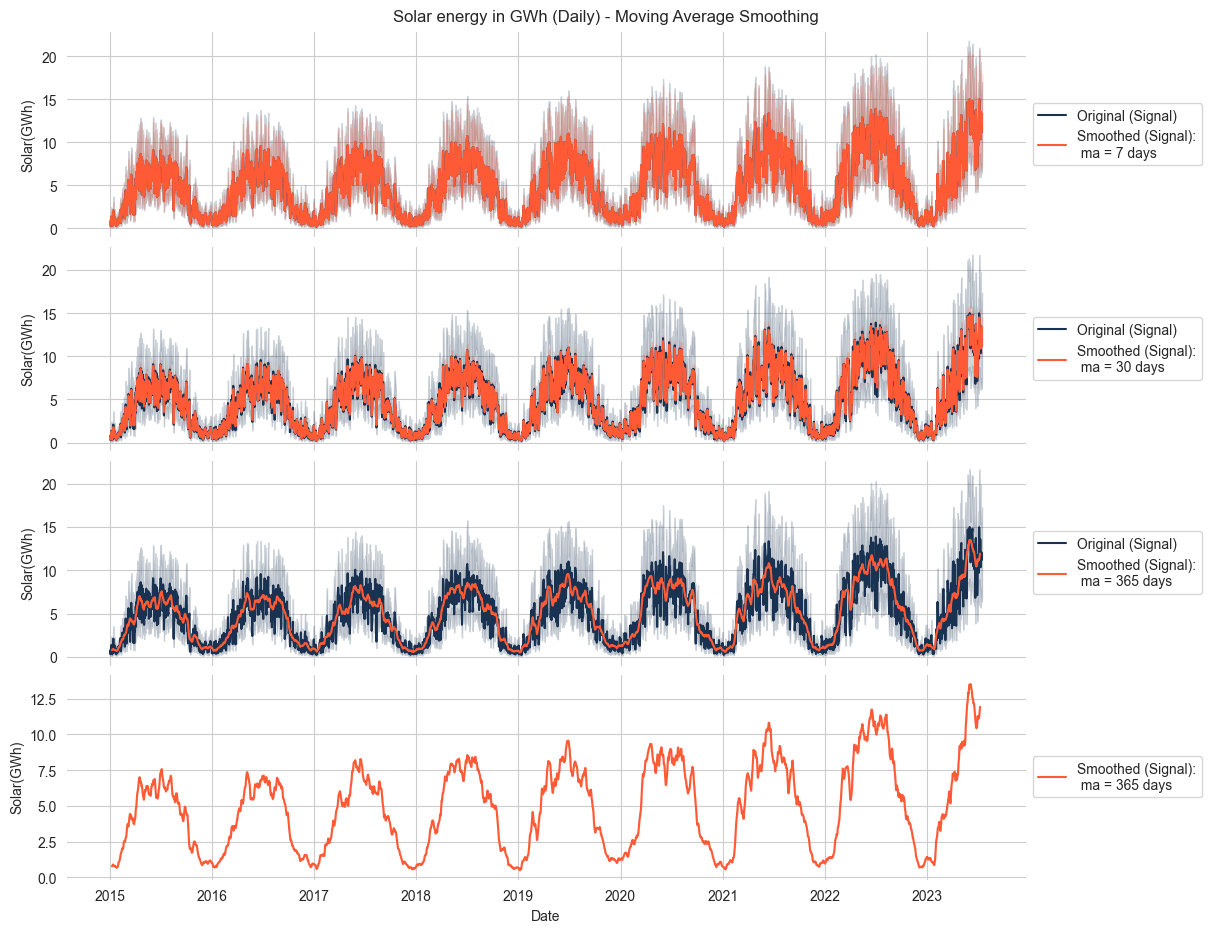

In [83]:
# Plot moving average of different length (week, month, year)
ma = [7, 30, 365]
#ma = [24, 30*24, 365*24]

smooth_daily_data_df = daily_data_df \
    .reset_index() \
    .assign(date = lambda x: x['Date'].transform(pd.to_datetime))

# Smooth and plot
fig, ax = plt.subplots(len(ma)+1, 1, figsize=(12, 9), constrained_layout=True, sharex=True)
plt.suptitle(title_main + ' ' + '(Daily) - Moving Average Smoothing', y=1.02);

for i, m in enumerate(ma):
    smooth_daily_data_df[f'target_SE_smooth_ma_{m}'] = smooth_daily_data_df[target].rolling(window=m,center=True).mean() #compute the rolling mean

    sns.lineplot(x='Date', y=target, label='Original (Signal)', data=smooth_daily_data_df,  ax=ax[i])
    sns.lineplot(x='Date', y=f'target_SE_smooth_ma_{m}', label=f'Smoothed (Signal):\n ma = {m} days', data=smooth_daily_data_df, color=NF_ORANGE, ax=ax[i])

    ax[i].legend(title='', loc='center left', bbox_to_anchor=(1, 0.5))
    ax[i].set(title='', ylabel=ylable_target);
        
sns.lineplot(x='Date', y=f'target_SE_smooth_ma_{m}', label=f'Smoothed (Signal):\n ma = {m} days', data=smooth_daily_data_df, color=sns_c[1], ax=ax[i+1])
ax[i+1].legend(title='', loc='center left', bbox_to_anchor=(1, 0.5))
ax[i+1].set(title='', ylabel=ylable_target);
    

## Time Series Decomposition

We can go deeper and decompose time series data into the different ingredients to understand what the sources of variation are we see in the data.
The method `seasonal_decompose` from `statsmodels.tsa.seasonal` can help us to decompose the daily data. This method is based on moving averages and returns the **trend**, **seasonality** and **residuals** of our timeseries.

The stpes inside of this function is:
* we first check for global trends using Moving average
* we de-trend our data by substituding the trend values from the original data
* then we estimate seasonal component by taking averages of each season's value - for example, the effect of January is the average of all de-trended January values in the data

We can define which seasonality we want to extract, lets pick a period of 365 Days, because this see

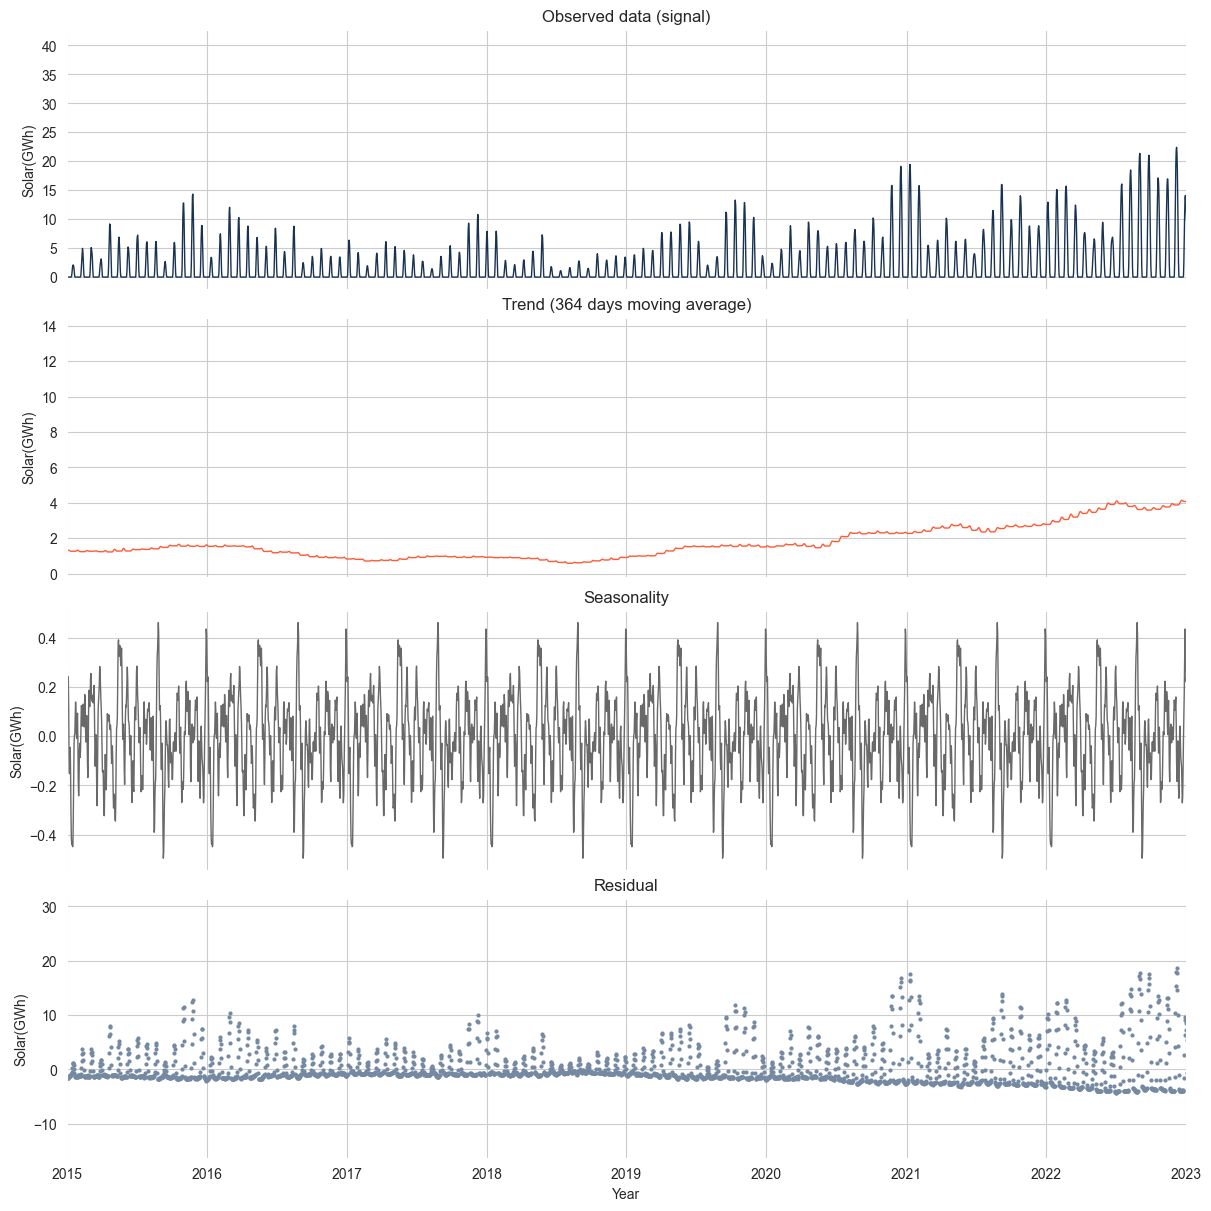

In [84]:
# We use the parameter `period` = 365 to extract the yearly seasonality. 
seas_decomp_yearly = seasonal_decompose(
    data_df[target], 
    model='additive', 
    two_sided=True,
    period= 365)

# Plots:
fig, ax = plt.subplots(4, 1, figsize=(12, 12), constrained_layout=True)

#Plot Signal
ax[0].set(title='Observed data (signal)', 
          ylabel=ylable_target)
seas_decomp_yearly.observed.plot(color=sns_c[0], 
                              linewidth=1,
                              sharex=True,
                              ax=ax[0])
#Plot Trend
ax[1].set(title='Trend (364 days moving average)', 
          ylabel=ylable_target)
seas_decomp_yearly.trend.plot(color=sns_c[1], 
                              linewidth=1,
                              sharex=True,
                              ax=ax[1])
#Plot Seasonality
ax[2].set(title='Seasonality', 
          ylabel=ylable_target)
seas_decomp_yearly.seasonal.plot(
                                color=sns_c[2], 
                                linewidth=1,
                                sharex=True,
                                ax=ax[2])
#Plot residual
ax[3].set(title='Residual', 
          ylabel=ylable_target);
ax[3].scatter(
    x=seas_decomp_yearly.resid.index,
    y=seas_decomp_yearly.resid,
    color=sns_c[3],
    s=4)

for i in range(4):
    ax[i].set_xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))
    ax[i].set(xlabel='Year');
 #plt.xlabel('Year')   
    
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

### Check decomposition of trend, seasonality and residue of original time series daily

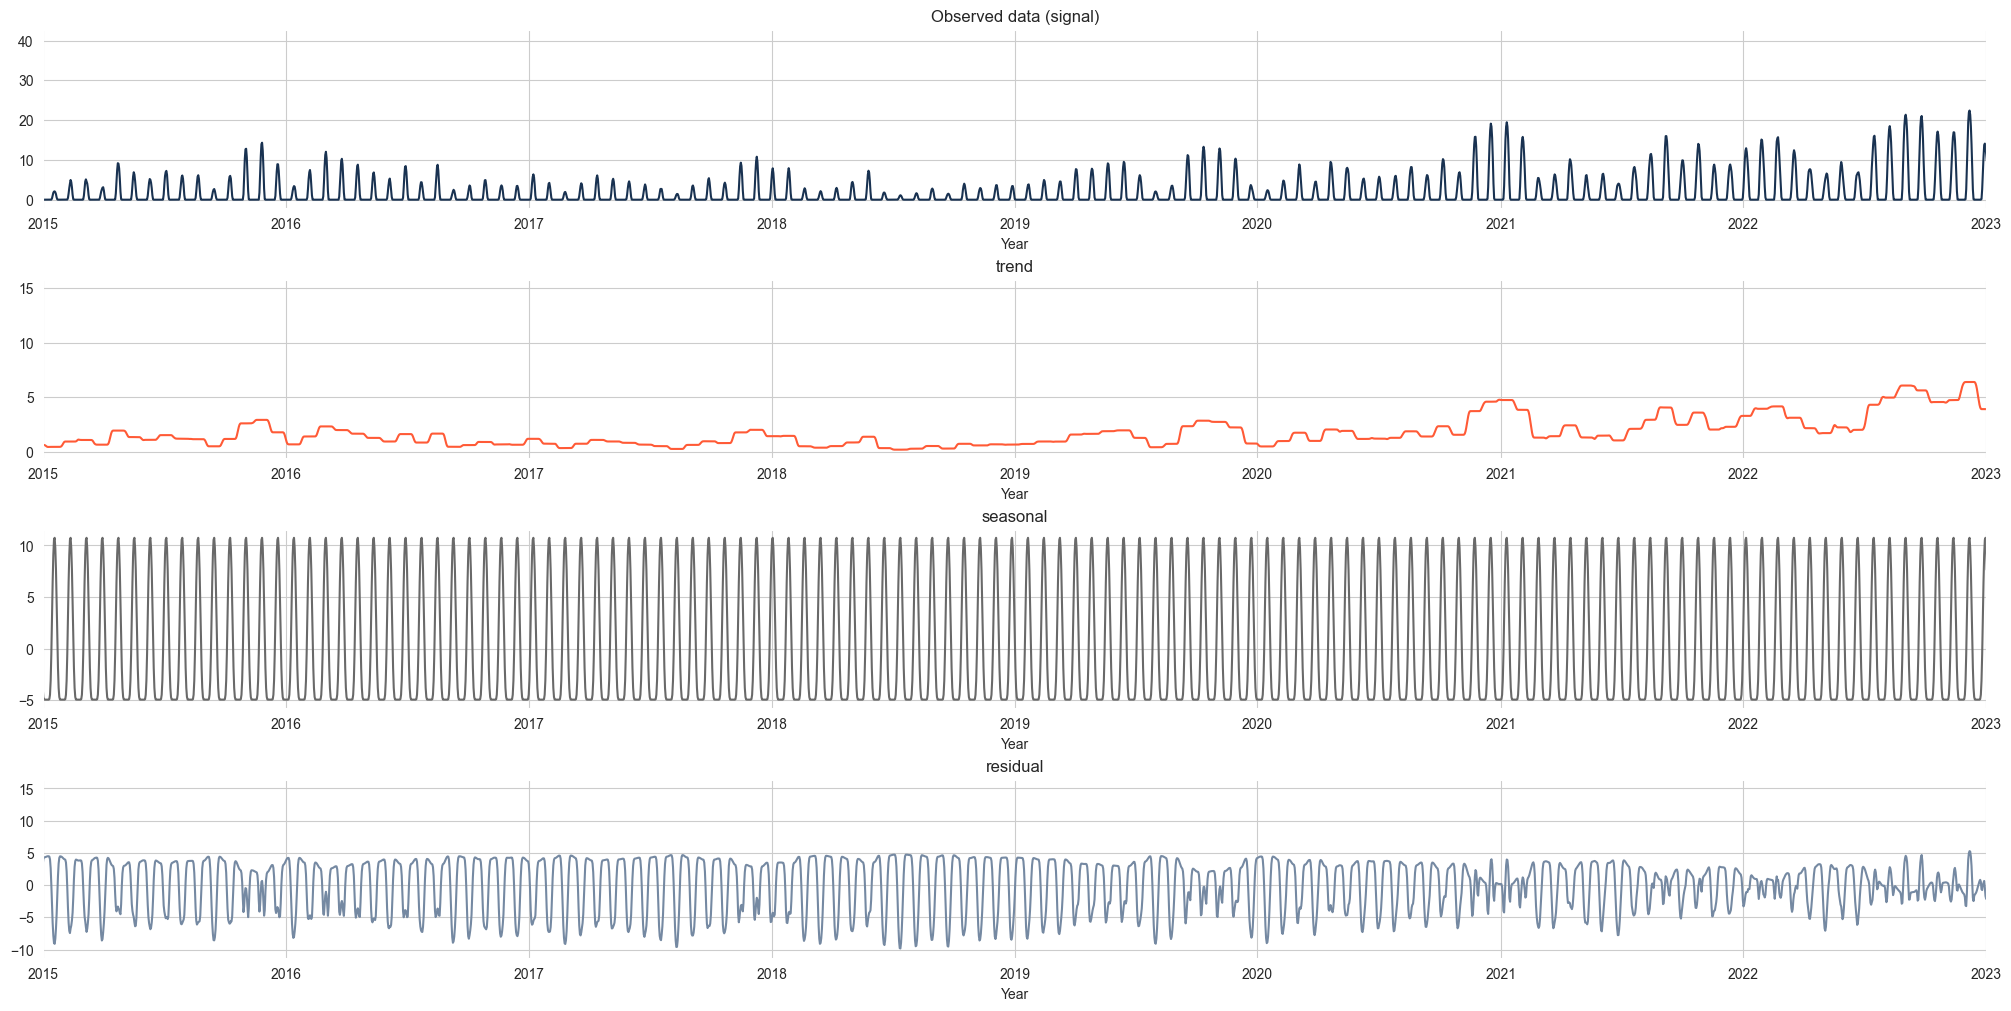

In [85]:
# Check decomposition of trend, seasonality and residue of original time series
decomposition = seasonal_decompose(x=data_df[target], 
                                   model='additive',
                                    two_sided=True,
                                   period=24)


fig, ax = plt.subplots(4, 1, figsize=(12, 12), constrained_layout=True)
decomposition.observed.plot(c=sns_c[0], ax=ax[0])
ax[0].set(title='Observed data (signal)')
decomposition.trend.plot(c=sns_c[1], ax=ax[1])
ax[1].set(title='trend')
decomposition.seasonal.plot(c=sns_c[2], ax=ax[2])
ax[2].set(title='seasonal')
decomposition.resid.plot(c=sns_c[3], ax=ax[3])
ax[3].set(title='residual')

for i in range(4):
    ax[i].set_xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))
    ax[i].set(xlabel='Year');
fig.set_size_inches(20, 10);

# Check for Stationarity

In order to apply an **ARIMA** model on the data we have to check if the time series is stationary. If not, we have to make it stationary. 

**RECAP**: 
* *Stationarity*: A time series is stationary if its statistical properties (e.g. mean, variance, etc.) are the same throughout the series, independently of the point in time where you observe it. There are no long-term predictable patterns such as trend or seasonality. Plots will show a roughly horizontal trend with constant variance. 

In order to check for stationarity we will apply three different methods. First, we will calculate and plot the rolling mean and rolling standard deviation. It they show an upward or downward trend or vary over time, then it is highly likely that our time series is non-stationary. Furthermore, we will use the **ADF** (Augmented Dickey-Fuller) and the **KPSS** (Kwiatkowski-Phillips-Schmidt-Shintests) tests. We have to be careful when interpreting the results: the null-hypothesis of the ADF test is that t

ADF Test:
Null Hypothesis: Not Stationary
ADF Statistic: -9.449319
p-value: 0.000000
----------------------------------------
KPSS Test:
Null Hypothesis: Stationary
KPSS Statistic: 8.045006
p-value: 0.010000
----------------------------------------


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_54866/939056977.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(Solar_Energy_target_, regression='c', nlags="legacy", store=False)


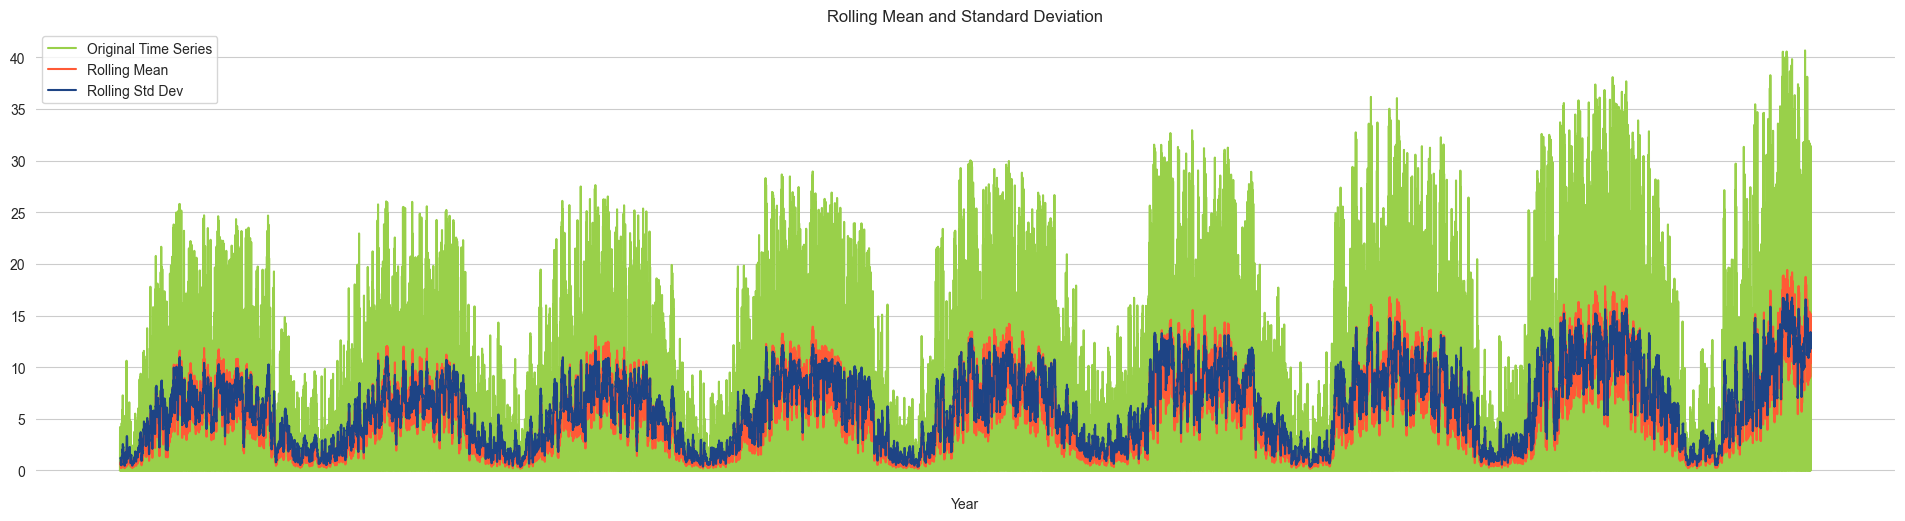

In [86]:
# Test for stationarity 
def stationarity_test(Solar_Energy_target_):
    rolling_mean = Solar_Energy_target_.rolling(30).mean()
    rolling_std_dev = Solar_Energy_target_.rolling(30).std()
    
    # Plot the statistics
    plt.figure(figsize=(24,6))
    plt.plot(Solar_Energy_target_, color='#99D04A',label='Original Time Series')
    plt.plot(rolling_mean, color='#FF5A36', label='Rolling Mean')
    plt.plot(rolling_std_dev, color='#1E4485', label = 'Rolling Std Dev')
    plt.xticks([])
    plt.legend(loc='best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.xlabel('Year')   
    
    # ADF test
    print("ADF Test:")
    adf_test = adfuller(Solar_Energy_target_,autolag='AIC')
    print('Null Hypothesis: Not Stationary')
    print('ADF Statistic: %f' % adf_test[0])
    print('p-value: %f' % adf_test[1])
    print('----'*10)
    
    # KPSS test
    print("KPSS Test:")
    kpss_test = kpss(Solar_Energy_target_, regression='c', nlags="legacy", store=False)
    print('Null Hypothesis: Stationary')
    print('KPSS Statistic: %f' % kpss_test[0])
    print('p-value: %f' % kpss_test[1])
    print('----'*10)
stationarity_test(data_df[target])


## De-trend the Time Series

We need to de-trend the time series. Therefore we have several options. 

**Differencing**: A new series is constructed by calculating the value at the current time by differencing the value of actual observation of current time and its previous time. $$value(t) = actual\_observation(t) - actual\_observation(t-1)$$


**Transformation**: Transforming the data using power, log, square root can help to linearize the data.

**Seasonal Differencing**: The values of the time series are calculated by differencing between one observation and its previous Nth observation. $$value(t) = actual\_observation(t) - actual\_observation(t-N)$$


**Fitting a model**: A linear regression model can be fitted to the time series. It will fit a linear trend on the time series. The values for the de-trended time series can be calculated by subtracting the actual observations with the values predicted by the model.
$$value(t) = actual\_observation(t) - pre

In [87]:
# De-trending the time series
data_df['SE_Detrend'] = (data_df[target] - data_df[target].shift(30))

ADF Test:
Null Hypothesis: Not Stationary
ADF Statistic: -49.641772
p-value: 0.000000
----------------------------------------
KPSS Test:
Null Hypothesis: Stationary
KPSS Statistic: 0.001847
p-value: 0.100000
----------------------------------------


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_54866/694189455.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(Solar_Energy_target_, regression='c', nlags='legacy', store=False)


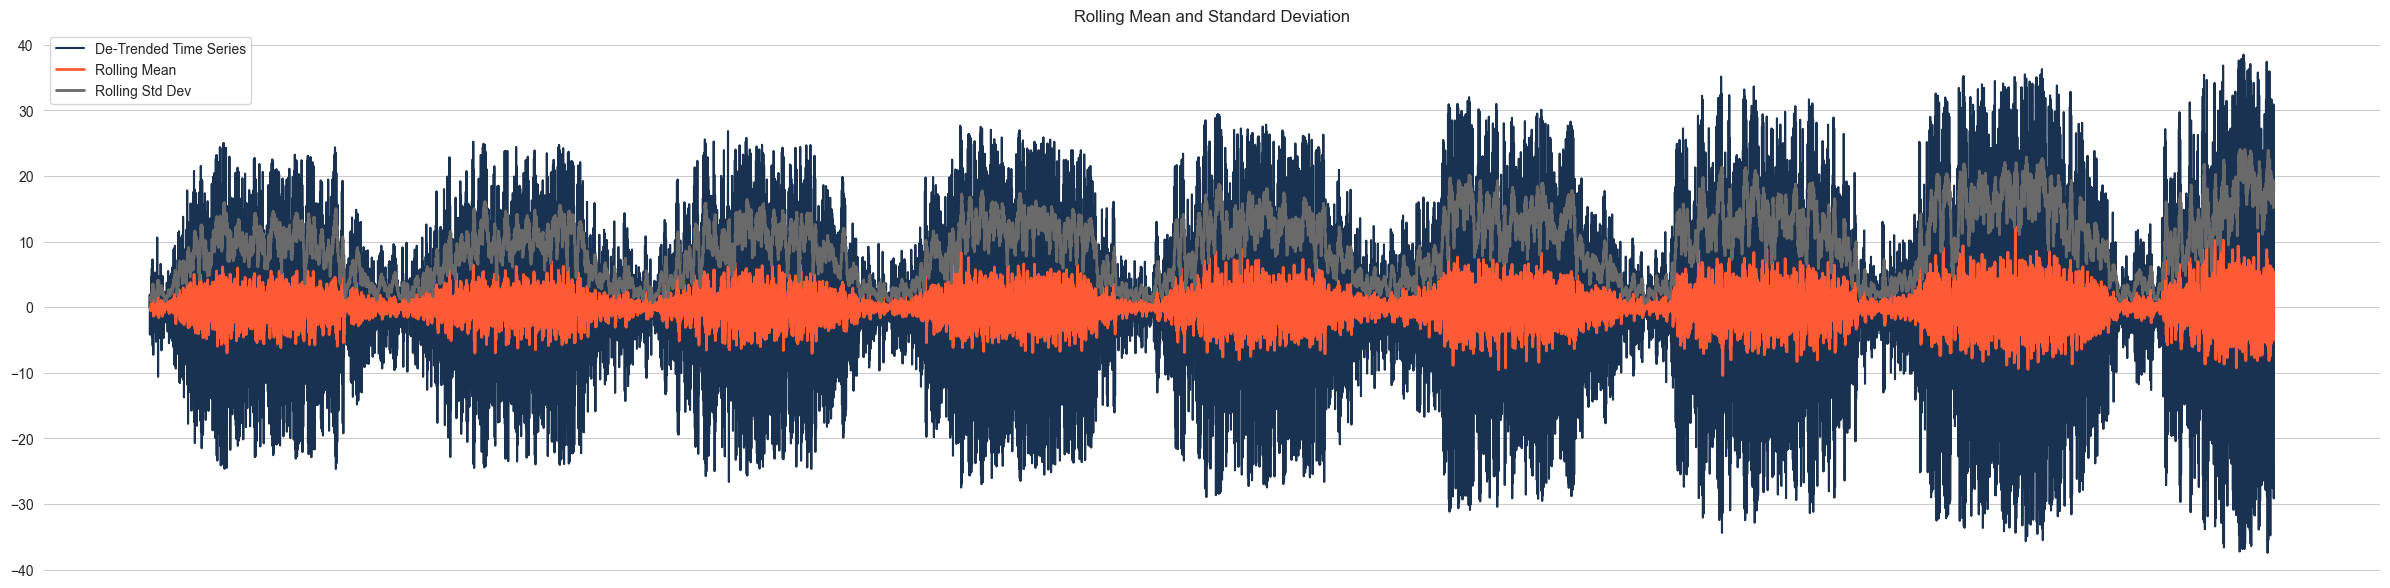

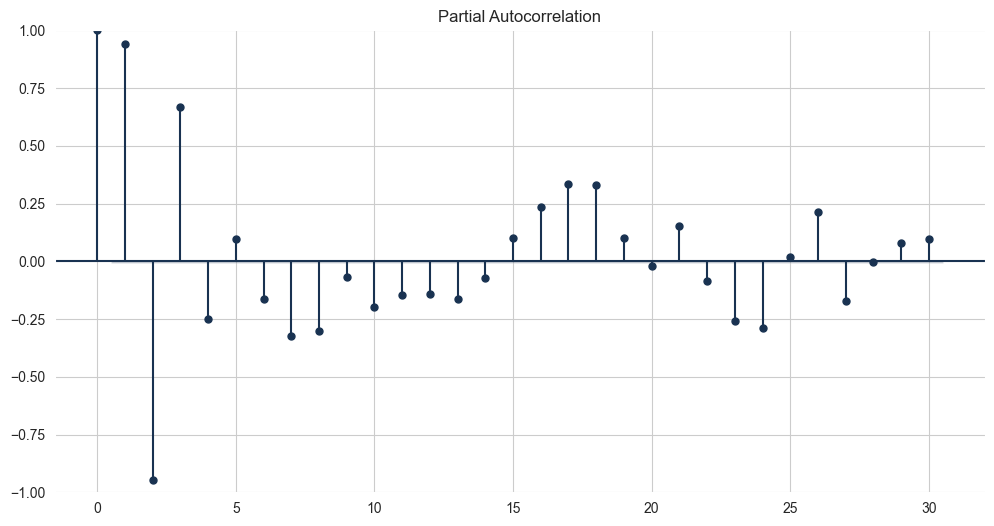

In [88]:
# Test for stationarity after de-trending 
def stationarity_test(Solar_Energy_target_):
    
    # Calculate rolling mean and rolling standard deviation
    rolling_mean = Solar_Energy_target_.rolling(30).mean()
    rolling_std_dev = Solar_Energy_target_.rolling(30).std()
  
    # Plot the statistics
    plt.figure(figsize=(24,6))
    plt.plot(Solar_Energy_target_,label='De-Trended Time Series')
    plt.plot(rolling_mean, label='Rolling Mean',linewidth=2.0)
    plt.plot(rolling_std_dev, label = 'Rolling Std Dev',linewidth=2.0)
    plt.xticks([])
    plt.legend(loc='best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.tight_layout()
    
    # ADF test
    print("ADF Test:")
    adf_test = adfuller(Solar_Energy_target_,autolag='AIC')
    print('Null Hypothesis: Not Stationary')
    print('ADF Statistic: %f' % adf_test[0])
    print('p-value: %f' % adf_test[1])
    print('----'*10)
    
    # KPSS test
    print("KPSS Test:")
    kpss_test = kpss(Solar_Energy_target_, regression='c', nlags='legacy', store=False)
    print('Null Hypothesis: Stationary')
    print('KPSS Statistic: %f' % kpss_test[0])
    print('p-value: %f' % kpss_test[1])
    print('----'*10)
    
stationarity_test(data_df['SE_Detrend'].dropna())

# Partial Autocorrelation Plot
pacf = plot_pacf(data_df['SE_Detrend'].dropna(), lags=30)

### Creating train and test sets
We will split our data and take the first part as our training set and the years after 2016 as a test set. Since we are dealing with a time series here we cannot split randomly as we are used to do. 

In [5]:
# Split data into train and test set
window=365#*24
df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
df_arima = df_arima.dropna()
##
##
#df_arima = data_df[target]
train_test_split_ratio = int(len(df_arima)*0.8)
train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

# Plotting the train and test set
plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.plot(train_data, 'red', label='Train data')
plt.plot(test_data, 'black', label='Test data')
plt.legend()
plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))

NameError: name 'data_df' is not defined

In [72]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data, seasonal = True, m=4, scoring='mse', stepwise= True)
#auto_arima(train_data, m=7, scoring='mse', seasonal = True,start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=12,start_P=0,seasonal=True,d=None, D=1,trace=False
                         ,error_action='ignore',suppress_warnings=True, stepwise=True)

# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.05) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

: 

: 

In [90]:
### fitting the model
#model = ARIMA(train['total_energy_generation_'], order=(2,1,2))
#model_fit = model.fit(disp=0)
#print(model_fit.summary())

## Model Building

After splitting the data we can now try to forcast the prices. We can use smoothing methods and ARIMA methods. While smoothing methods can be used for non-stationray data, ARIMA requires the data to be stationary. `auto_arima` can help us to make the series stationary and determine the optimal order for the ARIMA model.

We will perform multiple fits for each model to find the best hyperparamters. 

### Simple Exponential Smoothing

Simple Exponential Smoothing (SES) is used when the data doesn't contain any trend or seasonality. Smoothing Factor for level ($\alpha$) provides weightage to the influence of the observations. With larger values of $\alpha$ more attention is given to the most recent past observations whereas smaller values indicate that more past observations are being considered for forecasting. 

$$F_{t+1} = \alpha d_t + (1 - \alpha)F_t$$

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/

Simple Exponential Smoothing RMS :- 0.747 & Smoothing Level :- 0.15


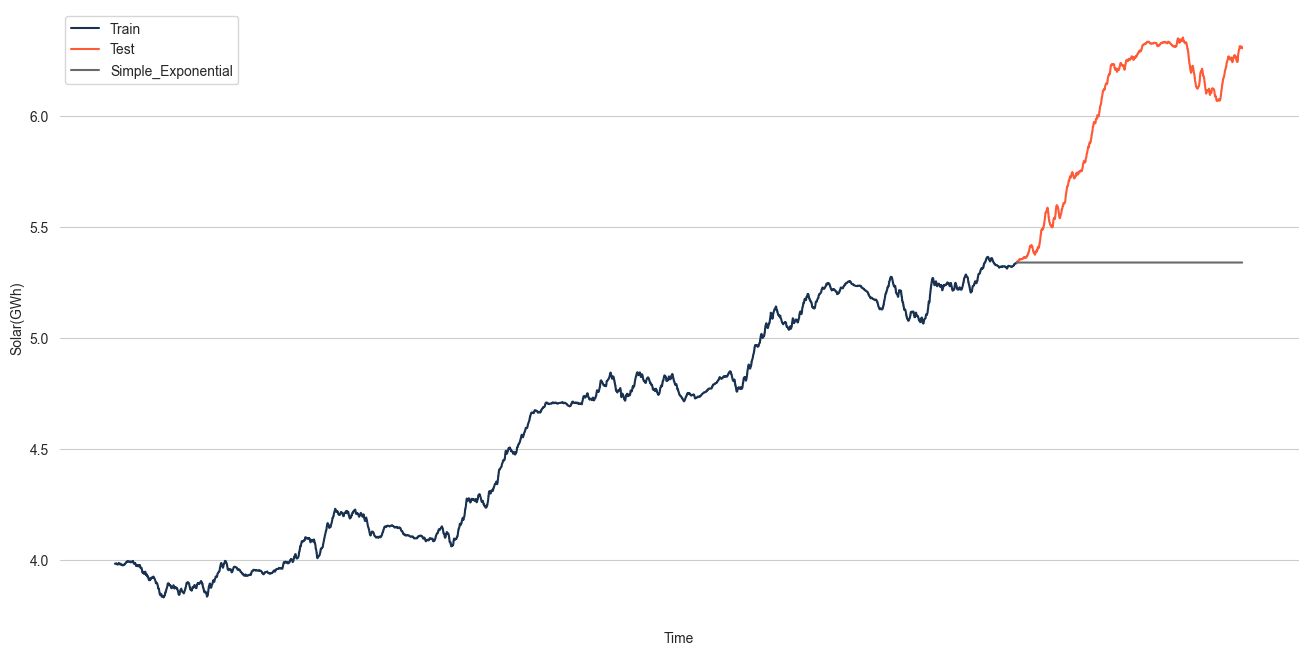

In [102]:
# Simple Exponential Smoothing Method
pred_values = test_data.copy()
pred_values = pd.DataFrame(pred_values)

simple_exponential_df = pd.DataFrame(columns = ['RMS','Smoothing Level'])

from itertools import permutations
perm = permutations(list(np.linspace(0.05,1,num=20)), 1)# origional
#perm = permutations(list(np.linspace(0.01,1,num=50)), 2)
for i in list(perm):
    fit_sim_exp = SimpleExpSmoothing(np.asarray(train_data)).fit(smoothing_level = i[0])
    pred_values['Simple_Exponential'] = fit_sim_exp.forecast(len(test_data))

    rms = round(sqrt(mean_squared_error(test_data.values, pred_values.Simple_Exponential)),3)
    simple_exponential_df = pd.concat([simple_exponential_df, pd.DataFrame({'RMS' : [rms] , 'Smoothing Level' : [i[0]]})], ignore_index=True)

opt_values = simple_exponential_df.loc[simple_exponential_df['RMS'] == min(simple_exponential_df['RMS']),['Smoothing Level']].values


# Use optimised values from the lists
fit_sim_exp = SimpleExpSmoothing(np.asarray(train_data)).fit(smoothing_level = opt_values[0][0])
pred_values['Simple_Exponential'] = fit_sim_exp.forecast(len(test_data))

plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Simple_Exponential'], label='Simple_Exponential')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')

rms_sim_exp = sqrt(mean_squared_error(test_data.values, pred_values.Simple_Exponential))
print("Simple Exponential Smoothing RMS :- " + str(round(rms_sim_exp,3)) + " & Smoothing Level :- "+str(round(opt_values[0][0],3)))

#plt.savefig("visualisations/Energy_Simple_Exponential.png",dpi=300)

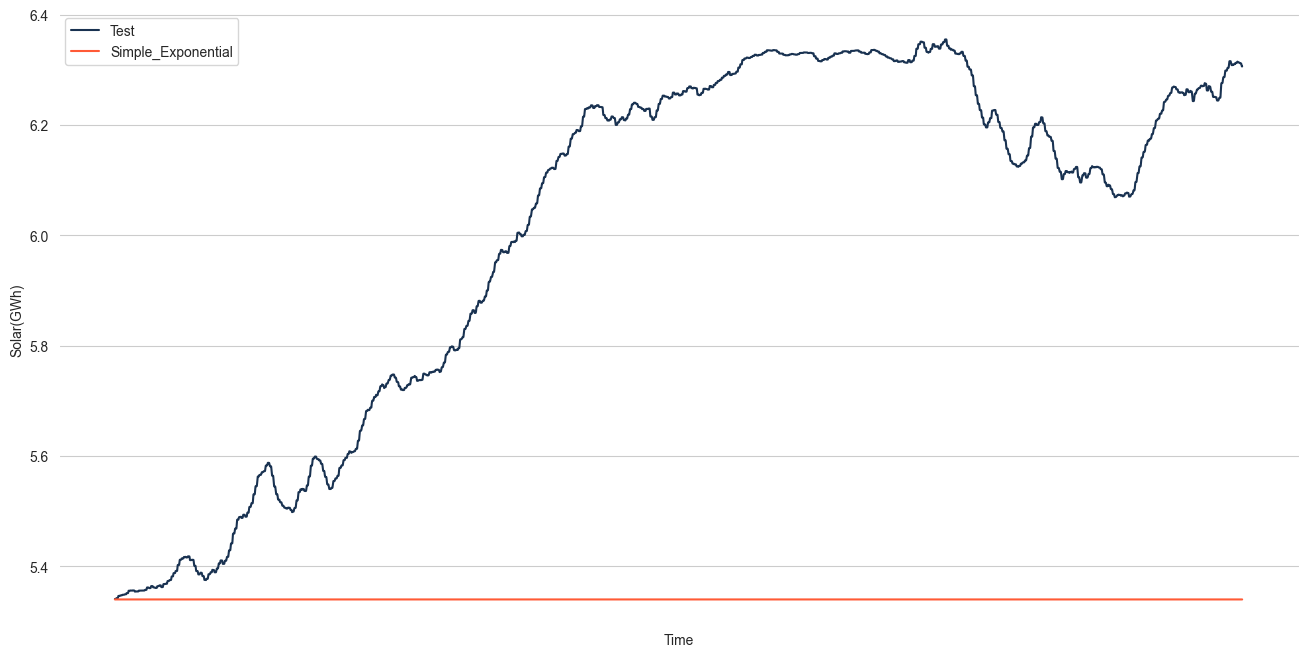

In [101]:
# Simple Exponential Smoothing Method
plt.figure(figsize=(16,8))
#plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Simple_Exponential'], label='Simple_Exponential')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')
#plt.savefig("visualisations/Energy_Simple_Exponential.png",dpi=300)

### Holt's Exponential Smoothing

Holt’s Exponential Smoothing takes the trend into account for forecasting the time series. We can use it when we have a trend but no seasonality in the data. It calculates the Smoothing value, which is the same used in SES for forecasting (first equation). Trend Coefficient (β) provides weightage to the difference in the consequent smoothing values and the previous trend estimate. The forecasting is a combination of the smoothing value and the trend estimate.

$$S_t = \alpha d_t + (1 - \alpha)F_t$$
$$b_t = \beta (S_t - S_{t-1}) + (1 - \beta) b_{t-1}$$
$$F_{t+1} = S_t + b_t$$

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_54866/2130103322.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_54866/2130103322.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: Estimat

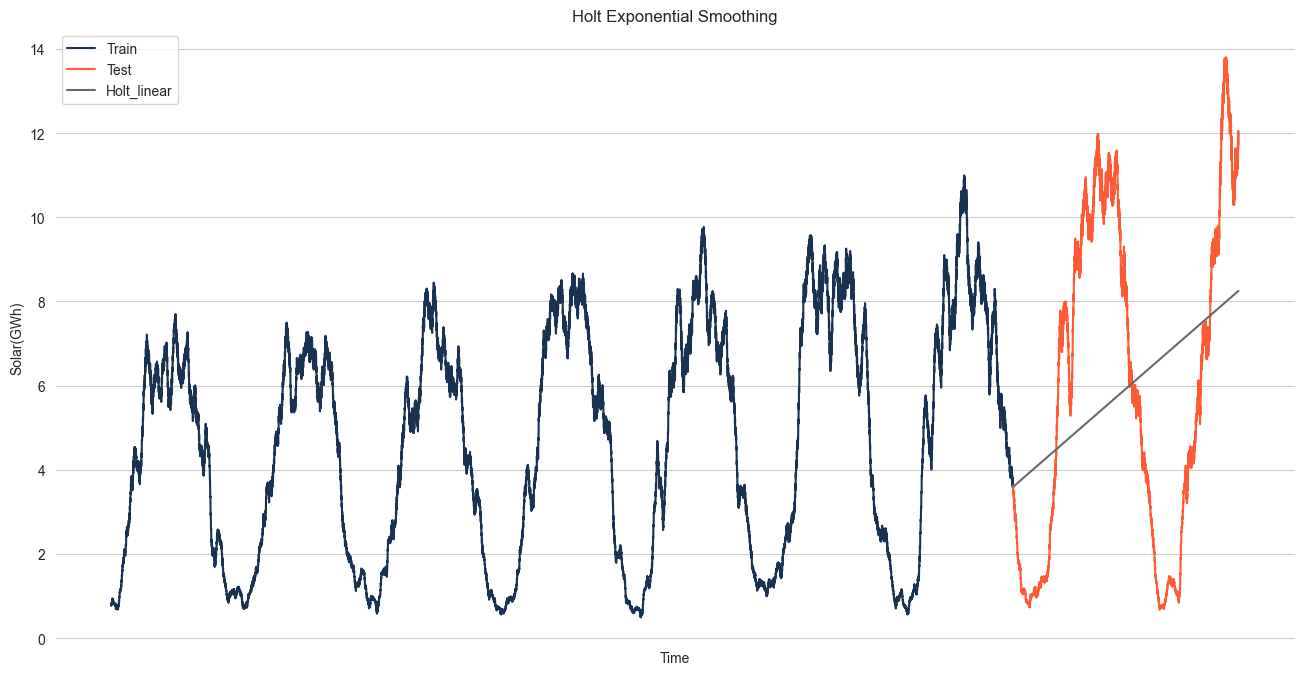

In [93]:
# Holt's Exponential Smoothing Method
holt_linear_df = pd.DataFrame(columns = ['RMS','Smoothing Level','Smoothing Slope'])

perm = permutations(list(np.linspace(0.05,1,num=20)), 2)
for i in list(perm):
    fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
    pred_values['Holt_linear'] = fit_holt.forecast(len(test_data))

    rms = round(sqrt(mean_squared_error(test_data.values, pred_values.Holt_linear)),3)
    #holt_linear_df = holt_linear_df.append(other = {'RMS' : rms , 'Smoothing Level' : i[0], 'Smoothing Slope':i[1]} , ignore_index=True)
    holt_linear_df = pd.concat([holt_linear_df, pd.DataFrame({'RMS' : [rms] , 'Smoothing Level' : [i[0]], 'Smoothing Slope':[i[1]]})], ignore_index=True)

opt_values = holt_linear_df.loc[holt_linear_df['RMS'] == min(holt_linear_df['RMS']),['Smoothing Level','Smoothing Slope']].values


# Using optimised values from the lists.
fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = opt_values[0][0],smoothing_slope=opt_values[0][1])
pred_values['Holt_linear'] = fit_holt.forecast(len(test_data))

plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Holt_linear'], label='Holt_linear')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')
plt.title('Holt Exponential Smoothing')
#plt.savefig("visualisations/Stock_Holt_winters.png",dpi=300)
rms_holt_exp = sqrt(mean_squared_error(test_data.values, pred_values.Holt_linear))
#print("Holt’s Exponential Smoothing RMS :- " + str(round(rms_holt_exp,3)) + " & Smoothing Level :- "+str(round(opt_values[0][0],3)) + " & Smoothing Slope :- "+str(round(opt_values[0][1],3)))


Text(0.5, 1.0, 'Holt Exponential Smoothing')

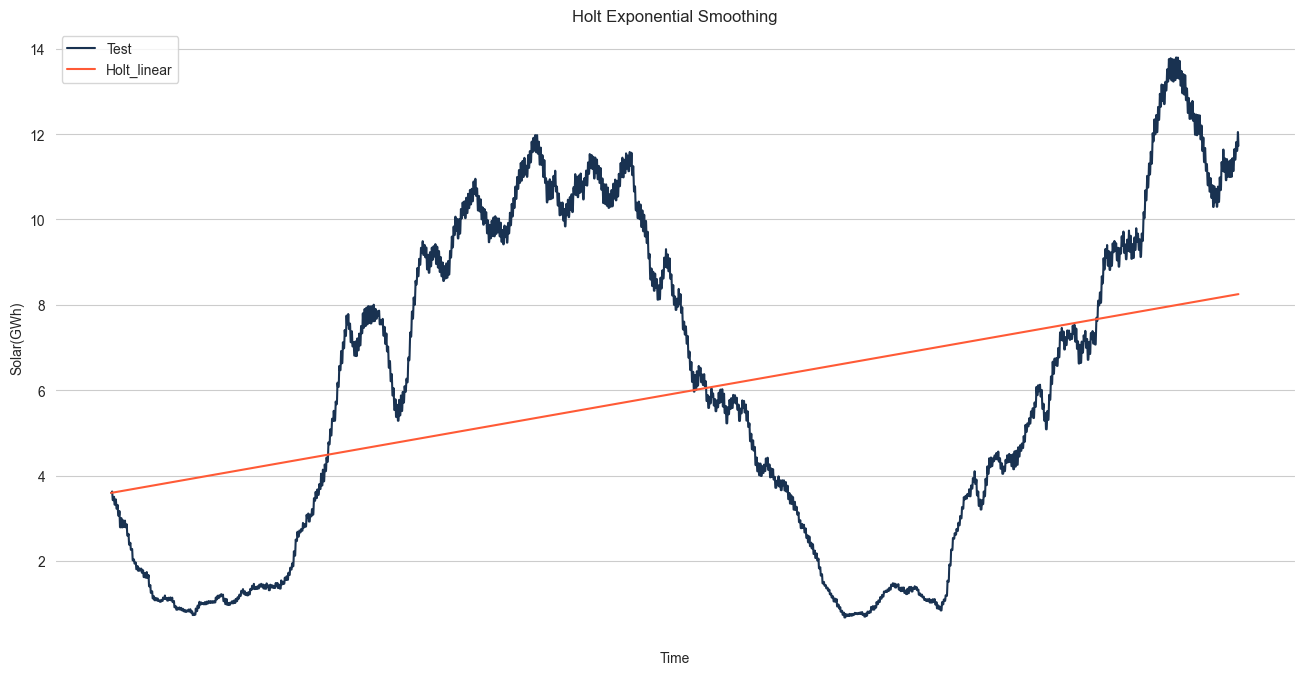

In [94]:
# Holt's Exponential Smoothing Method
plt.figure(figsize=(16,8))
#plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Holt_linear'], label='Holt_linear')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')
plt.title('Holt Exponential Smoothing')
#plt.savefig("visualisations/Stock_Holt_winters.png",dpi=300)


### Auto-Regressive Integrated Moving Average (ARIMA)

ARIMA model is a combination of Auto-Regressive and Moving Average model along with the Integration of differencing. Auto-Regressive model determines the relationship between an observation and a certain number of lagged observations. The Integrated part is the differencing of the actual observations to make the time series stationary. Moving Average determines the relationship between an observation and residual error obtained by using a moving average model on the lagged observations.

* *Auto-Regressive (p)*: Number of lag observations in the model. Also called lag order.
* *Integrated (d)*: Number of times the actual observations are differenced for stationarity. Also called degree of differencing.
* *Moving Average (q)*: Size of moving average window. Also called the order of moving average.

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59612
Model:               SARIMAX(3, 1, 2)   Log Likelihood              283913.216
Date:                Fri, 28 Jul 2023   AIC                        -567814.431
Time:                        17:57:46   BIC                        -567760.458
Sample:                             0   HQIC                       -567797.661
                              - 59612                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.3577      0.009    254.913      0.000       2.340       2.376
ar.L2         -1.9935      0.016   -122.818      0.000      -2.025      -1.962
ar.L3          0.5860      0.008     71.808      0.0

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Auto-Arima RMSE :- 4.575


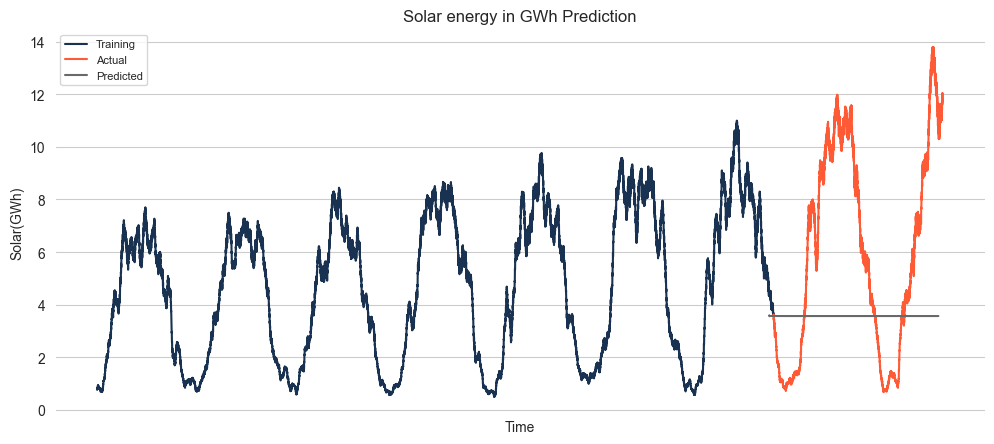

In [36]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
arima_model = auto_arima(train_data, seasonal = True, m=4, scoring='mse', stepwise= True)

# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.05) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

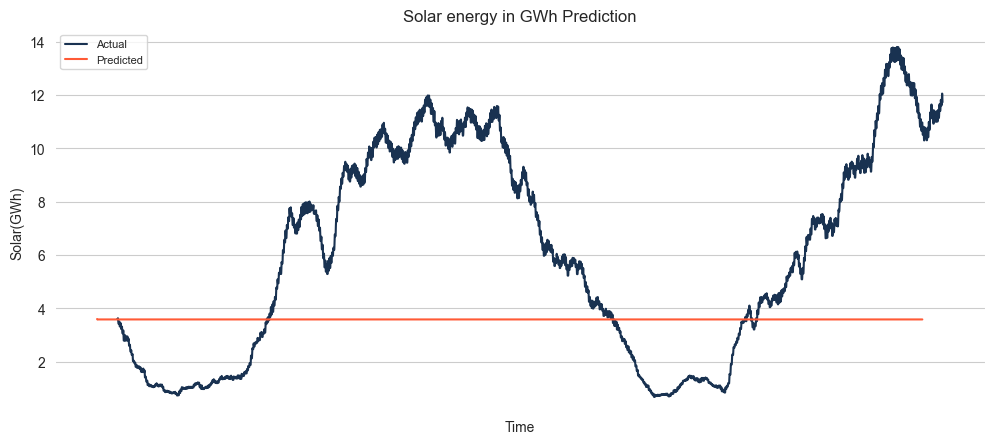

In [96]:
#Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
#plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

## Evaluation of the Models

To evaluate the performance of the model, we will use Root Mean Squared Error (RMSE) and compare which model performed the best.

In [97]:
# Printing RMSE of all the methods
print("RMSE of all the methods")
print("Auto-Arima: ", round(rms_auto_arima,3))
print("Simple Exponential Smoothing: ", round(rms_sim_exp,3))
print("Holt’s Exponential Smoothing: ", round(rms_holt_exp,3))

RMSE of all the methods
Auto-Arima:  4.569
Simple Exponential Smoothing:  4.529
Holt’s Exponential Smoothing:  3.702


In [112]:
# Temperature hourly development over time 
#fig, ax = plt.subplots()
#sns.lineplot(x='hour', y='total_energy_generation_mwh', data=data_df, ax=ax)
#ax.set(title='tot_eneg_generation_versus_hour', ylabel='total_energy_generation_mwh');
#fig.savefig("visualisations/tot_eneg_generation_versus_hour.png",dpi=300)

In [ ]:
#Output from mwh units

#RMSE of all the methods
#Auto-Arima:  12500.19
#Simple Exponential Smoothing:  11414.213
#Holt’s Exponential Smoothing:  10950.264